In [1]:
import os

os.environ["KERAS_BACKEND"] = "tensorflow"
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' # Only errors are logged
os.environ['TF_GPU_ALLOCATOR'] ='cuda_malloc_async'

import numpy as np
import keras
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import layers
from keras import ops

# TF imports related to tf.data preprocessing
from tensorflow import data as tf_data
from tensorflow import image as tf_image
from tensorflow.keras.utils import plot_model

keras.utils.set_random_seed(42)
from sklearn.model_selection import train_test_split

I0000 00:00:1777013610.965345  207037 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777013612.945383  207037 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
BATCH_SIZE = 32
NUM_CLASSES = 8
EPOCHS = 500
SAMPLE_RATE = 16000
OUT_SEQ_LEN = 72000

In [27]:
keras.backend.clear_session(free_memory=True)
train_ds =tf.keras.utils.image_dataset_from_directory(directory='dataset_stft_img/train',
image_size=(300, 300),
batch_size=BATCH_SIZE)
val_ds =tf.keras.utils.image_dataset_from_directory(directory='dataset_stft_img/val',
image_size=(300, 300),
batch_size=BATCH_SIZE)
test_ds =tf.keras.utils.image_dataset_from_directory(directory='dataset_stft_img/test',
image_size=(300, 300),
batch_size=BATCH_SIZE)

Found 7368 files belonging to 8 classes.
Found 636 files belonging to 8 classes.
Found 636 files belonging to 8 classes.


In [4]:
incv3 = keras.applications.InceptionV3(include_top=False,input_shape=(300,300,3), pooling = 'max')
# incv3.trainable = False
model = keras.Sequential([
  layers.Input(shape=(300,300,3),name='input'),

  incv3,
  layers.Dense((1024),activation='relu'),
  layers.Dense((512),activation='relu'),
  layers.Dense((NUM_CLASSES),activation = 'softmax',name='output')
])
model.summary()
keras.backend.clear_session(free_memory=True)
model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=1e-4),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[keras.metrics.SparseCategoricalAccuracy()],
)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ (None, 2048)           │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 8)              │         4,104 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,429,864 (93.19 MB)

 Trainable params: 24,395,432 (93.06 MB)

 Non-trainable params: 34,432 (134.50 KB)

In [5]:
history = model.fit(train_ds,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
          validation_data=val_ds,
        callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
        )]        )

Epoch 1/500
557/557 ━━━━━━━━━━━━━━━━━━━━ 116s 130ms/step - loss: 0.7579 - sparse_categorical_accuracy: 0.7238 - val_loss: 0.4467 - val_sparse_categorical_accuracy: 0.8302
Epoch 2/500
557/557 ━━━━━━━━━━━━━━━━━━━━ 39s 71ms/step - loss: 0.3747 - sparse_categorical_accuracy: 0.8621 - val_loss: 0.3920 - val_sparse_categorical_accuracy: 0.8616
Epoch 3/500
557/557 ━━━━━━━━━━━━━━━━━━━━ 39s 70ms/step - loss: 0.2318 - sparse_categorical_accuracy: 0.9168 - val_loss: 0.5291 - val_sparse_categorical_accuracy: 0.8459
Epoch 4/500
557/557 ━━━━━━━━━━━━━━━━━━━━ 39s 71ms/step - loss: 0.1558 - sparse_categorical_accuracy: 0.9451 - val_loss: 0.3874 - val_sparse_categorical_accuracy: 0.8789
Epoch 5/500
557/557 ━━━━━━━━━━━━━━━━━━━━ 39s 70ms/step - loss: 0.1029 - sparse_categorical_accuracy: 0.9647 - val_loss: 0.6234 - val_sparse_categorical_accuracy: 0.8632
Epoch 6/500
557/557 ━━━━━━━━━━━━━━━━━━━━ 39s 70ms/step - loss: 0.0859 - sparse_categorical_accuracy: 0.9716 - val_loss: 0.4670 - val_sparse_categorical_a

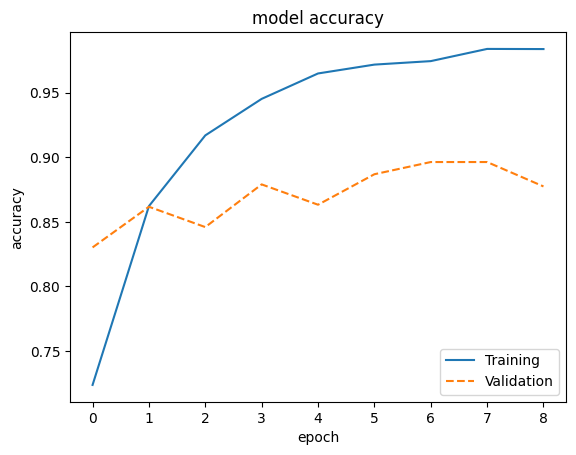

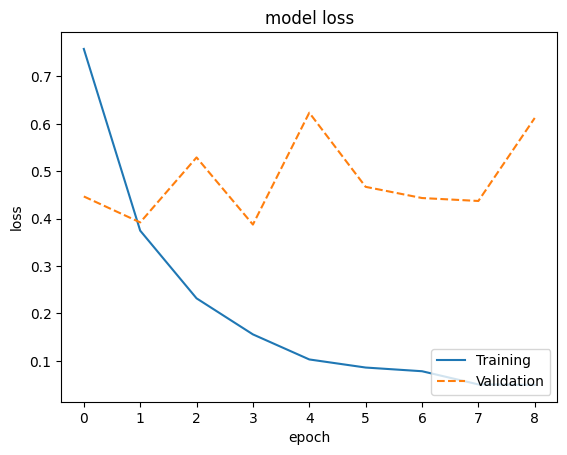

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.4855 - sparse_categorical_accuracy: 0.8648


[0.4854843318462372, 0.8647798895835876]

In [6]:
plt.plot(history.history['sparse_categorical_accuracy'])
plt.plot(history.history['val_sparse_categorical_accuracy'],linestyle='--')
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['Training', 'Validation'], loc='lower right')
plt.show()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'],linestyle='--')
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['Training', 'Validation'], loc='lower right')
plt.show()
model.evaluate(test_ds)

In [14]:
incv3_2 = keras.applications.InceptionV3(include_top=False,input_shape=(300,300,3), pooling='max')
incv3_2.trainable = False
model_2 = keras.Sequential([
  layers.Input(shape=(300,300,3),name='input'),
  incv3_2,
  layers.Dropout(0.3),
  # layers.GlobalAveragePooling2D(),
  # layers.BatchNormalization(),
  layers.Dense((512),activation='relu'),
  layers.Dense((NUM_CLASSES),activation = 'softmax',name='output')
])
model_2.summary()
keras.backend.clear_session(free_memory=True)
model_2.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=1e-4),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[keras.metrics.SparseCategoricalAccuracy()],
)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ (None, 2048)           │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 8)              │         4,104 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,855,976 (87.19 MB)

 Trainable params: 1,053,192 (4.02 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [15]:
history_2 = model_2.fit(train_ds,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
          validation_data=val_ds,
        callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
        )]        )

Epoch 1/500
557/557 ━━━━━━━━━━━━━━━━━━━━ 25s 34ms/step - loss: 25.9424 - sparse_categorical_accuracy: 0.3908 - val_loss: 6.2547 - val_sparse_categorical_accuracy: 0.6053
Epoch 2/500
557/557 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - loss: 10.8377 - sparse_categorical_accuracy: 0.4759 - val_loss: 2.7339 - val_sparse_categorical_accuracy: 0.6478
Epoch 3/500
557/557 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - loss: 7.1814 - sparse_categorical_accuracy: 0.4888 - val_loss: 2.4503 - val_sparse_categorical_accuracy: 0.6132
Epoch 4/500
557/557 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - loss: 4.8922 - sparse_categorical_accuracy: 0.4916 - val_loss: 1.9735 - val_sparse_categorical_accuracy: 0.5613
Epoch 5/500
557/557 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - loss: 2.9415 - sparse_categorical_accuracy: 0.4191 - val_loss: 1.7598 - val_sparse_categorical_accuracy: 0.3443
Epoch 6/500
557/557 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - loss: 1.7827 - sparse_categorical_accuracy: 0.3573 - val_loss: 1.5153 - val_sparse_categorical_a

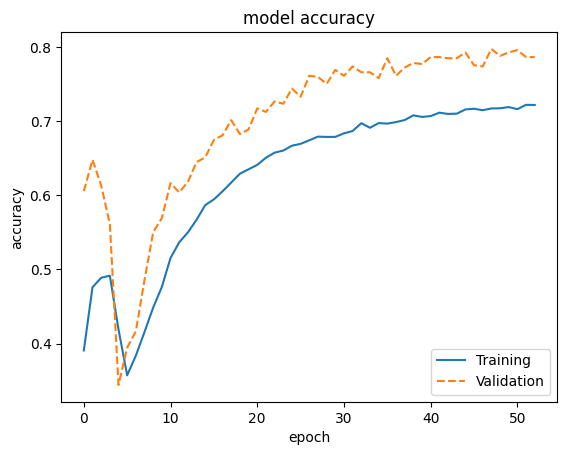

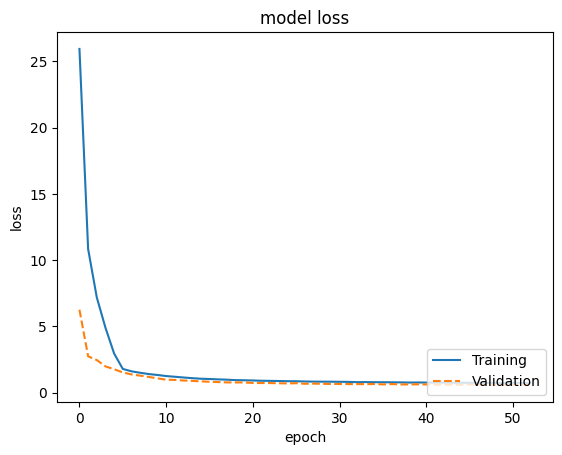

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.6318 - sparse_categorical_accuracy: 0.7689


[0.6318353414535522, 0.7688679099082947]

In [17]:
plt.plot(history_2.history['sparse_categorical_accuracy'])
plt.plot(history_2.history['val_sparse_categorical_accuracy'],linestyle='--')
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['Training', 'Validation'], loc='lower right')
plt.show()
plt.plot(history_2.history['loss'])
plt.plot(history_2.history['val_loss'],linestyle='--')
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['Training', 'Validation'], loc='lower right')
plt.show()
model_2.evaluate(test_ds)

In [ ]:
incv3_3 = keras.applications.InceptionV3(include_top=False,input_shape=(300,300,3))
incv3_3.trainable = False
model_3 = keras.Sequential([
  layers.Input(shape=(300,300,3),name='input'),
  incv3_3,
  layers.GlobalAveragePooling2D(),
  layers.BatchNormalization(),
  layers.Dense((128),activation='relu'),
  layers.Dropout(0.3),
  layers.Dense((NUM_CLASSES),activation = 'softmax',name='output')
])
model_3.summary()
keras.backend.clear_session(free_memory=True)
model_3.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=1e-4),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[keras.metrics.SparseCategoricalAccuracy()],
)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ (None, 8, 8, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_94          │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,074,280 (84.21 MB)

 Trainable params: 267,400 (1.02 MB)

 Non-trainable params: 21,806,880 (83.19 MB)

In [19]:
history_3 = model_3.fit(train_ds,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
          validation_data=val_ds,
        callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
        )]        )

Epoch 1/500
557/557 ━━━━━━━━━━━━━━━━━━━━ 26s 36ms/step - loss: 1.2947 - sparse_categorical_accuracy: 0.5318 - val_loss: 0.7996 - val_sparse_categorical_accuracy: 0.7138
Epoch 2/500
557/557 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - loss: 0.9142 - sparse_categorical_accuracy: 0.6663 - val_loss: 0.6957 - val_sparse_categorical_accuracy: 0.7406
Epoch 3/500
557/557 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - loss: 0.8028 - sparse_categorical_accuracy: 0.7031 - val_loss: 0.6436 - val_sparse_categorical_accuracy: 0.7516
Epoch 4/500
557/557 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - loss: 0.7530 - sparse_categorical_accuracy: 0.7183 - val_loss: 0.6056 - val_sparse_categorical_accuracy: 0.7783
Epoch 5/500
557/557 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - loss: 0.7068 - sparse_categorical_accuracy: 0.7337 - val_loss: 0.5877 - val_sparse_categorical_accuracy: 0.7814
Epoch 6/500
557/557 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - loss: 0.6718 - sparse_categorical_accuracy: 0.7506 - val_loss: 0.5722 - val_sparse_categorical_acc

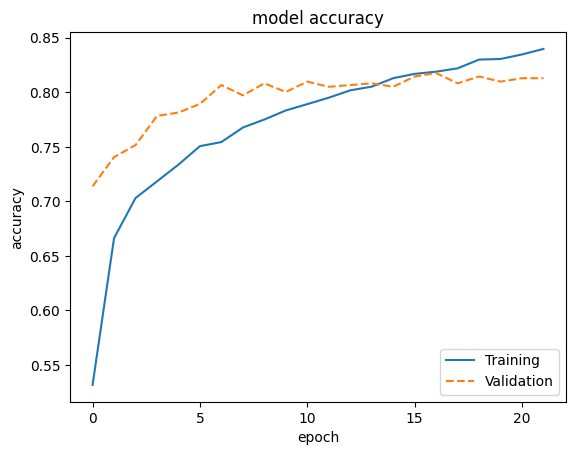

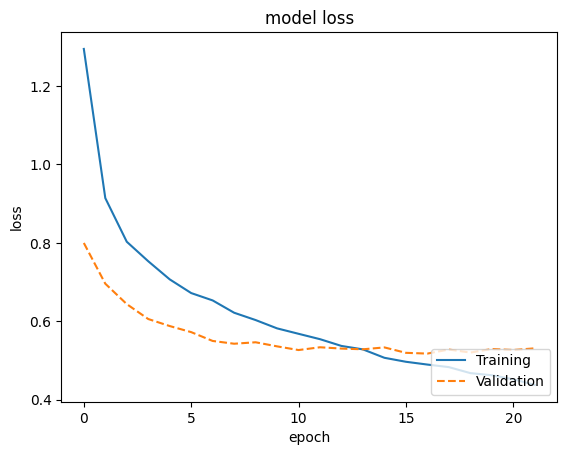

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.5410 - sparse_categorical_accuracy: 0.8066


[0.5410348773002625, 0.8066037893295288]

In [20]:
plt.plot(history_3.history['sparse_categorical_accuracy'])
plt.plot(history_3.history['val_sparse_categorical_accuracy'],linestyle='--')
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['Training', 'Validation'], loc='lower right')
plt.show()
plt.plot(history_3.history['loss'])
plt.plot(history_3.history['val_loss'],linestyle='--')
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['Training', 'Validation'], loc='lower right')
plt.show()
model_3.evaluate(test_ds)

In [4]:
incv3_4 = keras.applications.InceptionV3(include_top=False,input_shape=(300,300,3))
incv3_4.trainable = False
# for layer in incv3_4.layers[-50:]:
#     layer.trainable = True
model_4 = keras.Sequential([
  layers.Input(shape=(300,300,3),name='input'),
  layers.Rescaling(1./127.5, offset=-1),
  incv3_4,
  layers.GlobalAveragePooling2D(),
  layers.BatchNormalization(),
  layers.Dense((128),activation='relu'),
  layers.Dropout(0.3),
  layers.Dense((NUM_CLASSES),activation = 'softmax',name='output')
])
model_4.summary()
keras.backend.clear_session(free_memory=True)
model_4.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=1e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[keras.metrics.SparseCategoricalAccuracy()],
)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 8, 8, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_94          │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,074,280 (84.21 MB)

 Trainable params: 267,400 (1.02 MB)

 Non-trainable params: 21,806,880 (83.19 MB)

In [5]:
history_4 = model_4.fit(train_ds,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
          validation_data=val_ds,
        callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
        )]        )

Epoch 1/500
557/557 ━━━━━━━━━━━━━━━━━━━━ 36s 45ms/step - loss: 2.1145 - sparse_categorical_accuracy: 0.2747 - val_loss: 1.4390 - val_sparse_categorical_accuracy: 0.4764
Epoch 2/500
557/557 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - loss: 1.5521 - sparse_categorical_accuracy: 0.4456 - val_loss: 1.1826 - val_sparse_categorical_accuracy: 0.5723
Epoch 3/500
557/557 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - loss: 1.3446 - sparse_categorical_accuracy: 0.5153 - val_loss: 1.0533 - val_sparse_categorical_accuracy: 0.6164
Epoch 4/500
557/557 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - loss: 1.2275 - sparse_categorical_accuracy: 0.5599 - val_loss: 0.9713 - val_sparse_categorical_accuracy: 0.6384
Epoch 5/500
557/557 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - loss: 1.1423 - sparse_categorical_accuracy: 0.5840 - val_loss: 0.9109 - val_sparse_categorical_accuracy: 0.6619
Epoch 6/500
557/557 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - loss: 1.0745 - sparse_categorical_accuracy: 0.6108 - val_loss: 0.8679 - val_sparse_categorical_acc

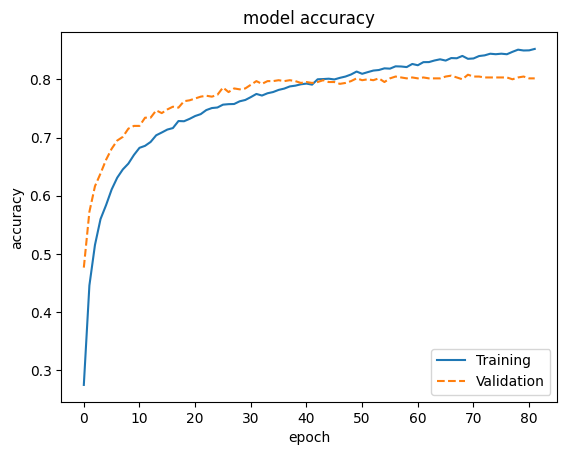

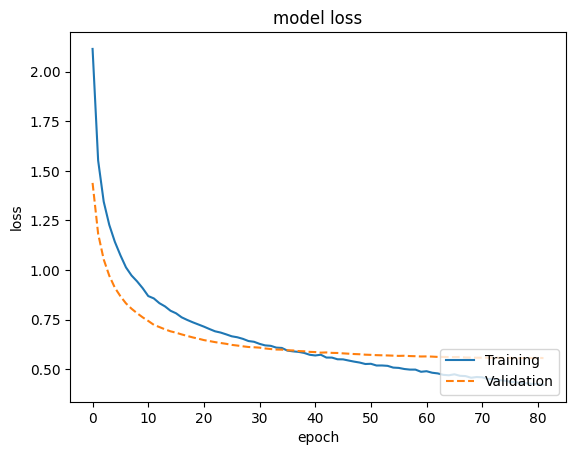

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.5068 - sparse_categorical_accuracy: 0.8019


[0.5068264603614807, 0.801886796951294]

In [6]:
plt.plot(history_4.history['sparse_categorical_accuracy'])
plt.plot(history_4.history['val_sparse_categorical_accuracy'],linestyle='--')
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['Training', 'Validation'], loc='lower right')
plt.show()
plt.plot(history_4.history['loss'])
plt.plot(history_4.history['val_loss'],linestyle='--')
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['Training', 'Validation'], loc='lower right')
plt.show()
model_4.evaluate(test_ds)

In [28]:
incv3_5 = keras.applications.InceptionV3(include_top=False,input_shape=(300,300,3))
incv3_5.trainable = False
for layer in incv3_5.layers[-20:]:
    layer.trainable = True
model_5 = keras.Sequential([
  layers.Input(shape=(300,300,3),name='input'),
  layers.Rescaling(1./127.5, offset=-1),
  incv3_5,
  layers.GlobalAveragePooling2D(),
  layers.BatchNormalization(),
  layers.Dense((128),activation='gelu',
                   kernel_regularizer=keras.regularizers.L1L2(l1=1e-5, l2=1e-4),

               ),
  layers.Dropout(0.4),
  layers.Dense((NUM_CLASSES),activation = 'softmax',name='output')
])
model_5.summary()
keras.backend.clear_session(free_memory=True)
model_5.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=1e-5,weight_decay=1e-4),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[keras.metrics.SparseCategoricalAccuracy()],
)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 8, 8, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_94          │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,074,280 (84.21 MB)

 Trainable params: 2,202,760 (8.40 MB)

 Non-trainable params: 19,871,520 (75.80 MB)

In [29]:
history_5 = model_5.fit(train_ds,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
          validation_data=val_ds,
        callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
        )]        )

Epoch 1/500
231/231 ━━━━━━━━━━━━━━━━━━━━ 26s 78ms/step - loss: 2.2270 - sparse_categorical_accuracy: 0.2966 - val_loss: 1.4117 - val_sparse_categorical_accuracy: 0.5377
Epoch 2/500
231/231 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 1.5121 - sparse_categorical_accuracy: 0.5003 - val_loss: 1.0200 - val_sparse_categorical_accuracy: 0.6918
Epoch 3/500
231/231 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 1.2939 - sparse_categorical_accuracy: 0.5721 - val_loss: 0.8835 - val_sparse_categorical_accuracy: 0.7248
Epoch 4/500
231/231 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 1.1347 - sparse_categorical_accuracy: 0.6261 - val_loss: 0.8171 - val_sparse_categorical_accuracy: 0.7516
Epoch 5/500
231/231 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 1.0345 - sparse_categorical_accuracy: 0.6668 - val_loss: 0.7656 - val_sparse_categorical_accuracy: 0.7657
Epoch 6/500
231/231 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.9587 - sparse_categorical_accuracy: 0.6880 - val_loss: 0.7387 - val_sparse_categorical_accuracy

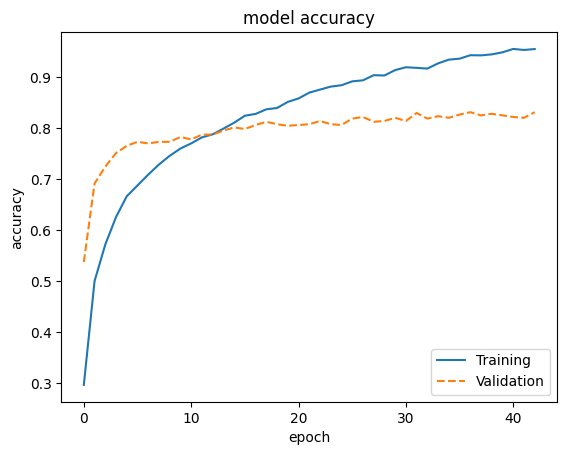

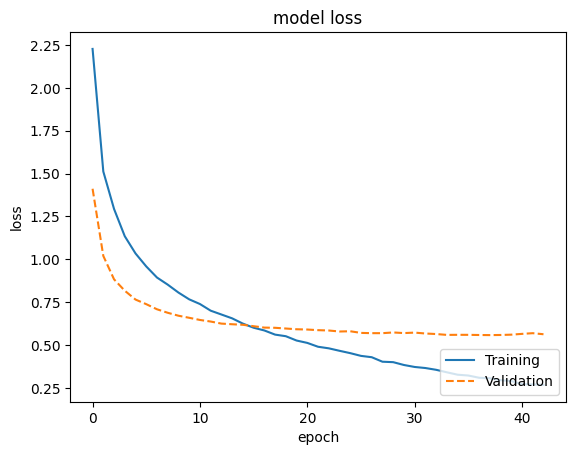

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.5550 - sparse_categorical_accuracy: 0.8412


[0.5549768209457397, 0.8411949872970581]

In [30]:
plt.plot(history_5.history['sparse_categorical_accuracy'])
plt.plot(history_5.history['val_sparse_categorical_accuracy'],linestyle='--')
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['Training', 'Validation'], loc='lower right')
plt.show()
plt.plot(history_5.history['loss'])
plt.plot(history_5.history['val_loss'],linestyle='--')
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['Training', 'Validation'], loc='lower right')
plt.show()
model_5.evaluate(test_ds)